# Fourier Transforms: Decomposing Signals into Frequency, Amplitude, and Phase

### Why this notebook?
In geophysics, we often work with signals that look complex in the time or space domain.
Fourier transforms provide a way to reorganise that information into a frequency (or wavelength) representation.

This notebook builds intuition for:
- What information a Fourier transform contains
- What information it does *not* contain
- Why amplitude and phase matter
- Why sampling and padding affect what we see

Although we use **time** here, the same mathematics applies to **space** in potential field methods.

### Learning objectives

By the end of this demo, you should be able to:
- Explain what information is contained in a Fourier transform
- Describe a signal in terms of frequency, amplitude, and phase
- Explain why phase affects signal shape but not spectral magnitude
- Understand the role of sampling, padding, and windowing
- Make a clear analogy between time–frequency and space–wavenumber analysis

## Setup and imports

**Objective:**  
Load the libraries we need and define plotting behaviour so results are clear and reproducible.

Nothing conceptually important happens here — this just sets the environment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Checkbox
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True
})

**Key point:**
Fourier transforms are implemented numerically, but the ideas we explore are mathematical and physical, not software‑specific.

## Defining the time axis and sampling

**Objective:**  
Make sampling explicit from the very beginning.

A Fourier transform does not exist independently of:
- Sampling interval
- Sampling frequency
- Total record length

These same ideas will later control spatial sampling in gravity and magnetics.


In [2]:
# Sampling parameters
fs = 256.0          # sampling frequency (Hz)
dt = 1 / fs
T = 4.0             # total record length (s)

t = np.arange(0, T, dt)
N = len(t)

print(f"Sampling frequency: {fs} Hz")
print(f"Number of samples: {N}")

Sampling frequency: 256.0 Hz
Number of samples: 1024


**Key observations:**
- Sampling frequency sets the highest resolvable frequency (Nyquist).
- Record length controls frequency resolution.
- Exactly the same logic applies when sampling in space instead of time.

Later translation:
- Time → distance
- Sampling frequency → station spacing


## Defining frequency content

**Objective:**  
Specify which frequencies exist in the signal *before* we construct it.

We deliberately choose known frequencies so the FFT result can be interpreted unambiguously.

In [3]:
# Frequencies present in the signal (Hz)
frequencies = np.arange(1, 33)  # 1–32 Hz

**Key idea:**
The Fourier transform does not discover frequencies — it reveals frequencies that are already present in the data.

## Signal construction and FFT helper functions

**Objective:**  
Define reusable functions that:
- Construct a signal with controlled amplitude and phase
- Compute a Fourier transform with optional padding and windowing
- Compute the exact frequency–amplitude and frequency–phase relationships used toconstruct the signal, so we can compare them directly with the FFT estimate.These represent the *true model parameters*.

This keeps the interactive exploration clean and readable.

### Amplitude scaling in the FFT

The FFT returns coefficients whose magnitude depends on:
- The number of samples
- Whether a window is applied

To compare the FFT result with the amplitudes used to construct the signal,
we explicitly undo this deterministic scaling.

This does **not** make the FFT exact — it simply puts the result
back into physical amplitude units.

Any remaining mismatch reflects real limitations of discrete sampling,
not a flaw in the Fourier transform.

In [4]:
def build_signal(t, freqs, amp_exp=1.0, phase_type="linear", phase_shift=0.0):
    """
    Construct a multi-frequency signal with structured amplitude and phase.
    """
    signal = np.zeros_like(t)

    for f in freqs:
        amplitude = f**(-amp_exp)

        if phase_type == "zero":
            phase = 0.0
        elif phase_type == "linear":
            phase = -2 * np.pi * f * phase_shift
        elif phase_type == "scrambled":
            phase = np.random.uniform(0, 2*np.pi)
        else:
            phase = 0.0

        signal += amplitude * np.sin(2 * np.pi * f * t + phase)

    return signal


def compute_fft(signal, dt, pad_factor=1, window=True):
    N = len(signal)

    if window:
        win = np.hanning(N)
        signal = signal * win
        G = np.mean(win)
    else:
        G = 1.0

    Npad = pad_factor * N
    fft_vals = np.fft.rfft(signal, n=Npad)
    freqs = np.fft.rfftfreq(Npad, dt)

    # Amplitude correction (one-sided spectrum)
    amplitude = (2.0 / (N * G)) * np.abs(fft_vals)
    phase = np.angle(fft_vals)

    return freqs, amplitude, phase


def ideal_spectra(freqs, amp_exp=1.0, phase_type="linear", phase_shift=0.0):
    """
    Compute the ideal amplitude and phase used to construct the signal.
    """
    amplitudes = freqs**(-amp_exp)

    if phase_type == "zero":
        phases = np.zeros_like(freqs)
    elif phase_type == "linear":
        phases = -2 * np.pi * freqs * phase_shift
    elif phase_type == "scrambled":
        # For scrambled phase, the 'ideal' phase is undefined
        phases = np.nan * np.ones_like(freqs)
    else:
        phases = np.zeros_like(freqs)

    return amplitudes, phases

def coherent_gain(window, N):
    if not window:
        return 1.0
    # Hann window
    return np.mean(np.hanning(N))

**Key ideas introduced here:**
- Amplitude is frequency‑dependent, not random
- Phase can be structured (e.g., time shifts)
- Padding and windowing affect how the FFT *looks*, not the underlying physics


## Interactive exploration of Fourier transforms

**Objective:**  
Explore how changing amplitude, phase, padding, and windowing affects:
- The time‑domain signal
- The amplitude spectrum
- The phase spectrum

This is the core conceptual experiment of the demo.


In [5]:
def explore_fft(amp_exp=1.0,
                phase_type="linear",
                phase_shift=0.2,
                pad_factor=4,
                window=True):

    # --- Build signal ---
    signal = build_signal(
        t,
        frequencies,
        amp_exp=amp_exp,
        phase_type=phase_type,
        phase_shift=phase_shift
    )

    # --- FFT ---
    fft_freqs, fft_amp, fft_phase = compute_fft(
        signal,
        dt,
        pad_factor=pad_factor,
        window=window
    )

    # --- Ideal spectra ---
    ideal_amp, ideal_phase = ideal_spectra(
        frequencies,
        amp_exp=amp_exp,
        phase_type=phase_type,
        phase_shift=phase_shift
    )

    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    # -------------------------
    # Time-domain signal
    # -------------------------
    axs[0].plot(t, signal, color="black")
    axs[0].set_ylabel("Amplitude")
    axs[0].set_title("Time-domain signal")

    # -------------------------
    # Amplitude spectrum
    # -------------------------
    axs[1].stem(
        fft_freqs,
        fft_amp,
        basefmt=" ",
        linefmt="C0-",
        markerfmt="C0o",
        label="FFT estimate"
    )

    axs[1].plot(
        frequencies,
        ideal_amp,
        "ro",
        label="Ideal input"
    )

    axs[1].set_xlim(0, 40)
    axs[1].set_ylabel("Amplitude")
    axs[1].set_title("Amplitude spectrum")
    axs[1].legend()

    # -------------------------
    # Phase spectrum
    # -------------------------
    fft_phase_unwrapped = np.unwrap(fft_phase)

    axs[2].stem(
        fft_freqs,
        fft_phase,
        basefmt=" ",
        linefmt="C1-",
        markerfmt="C1o",
        label="FFT estimate"
    )

    if phase_type != "scrambled":
        axs[2].plot(
            frequencies,
            ideal_phase,
            "ro",
            label="Ideal input"
        )

    axs[2].set_xlim(0, 40)
    axs[2].set_ylabel("Phase (rad)")
    axs[2].set_xlabel("Frequency (Hz)")
    axs[2].set_title("Phase spectrum")
    axs[2].legend()

    # for a, b, c in zip(frequencies, ideal_amp, ideal_phase):
    #     print(a, b, c)

    # for a, b, c in zip(fft_freqs, fft_amp, fft_phase):
    #     print(a, b, c)

## Interactive controls

**Objective:**  
Use sliders and toggles to explore:
- How amplitude decay affects spectra
- How phase affects waveform shape
- How padding stabilises spectral estimates

interactive(children=(FloatSlider(value=1.0, description='Amplitude ∝ f⁻ⁿ', max=2.0), Dropdown(description='Ph…

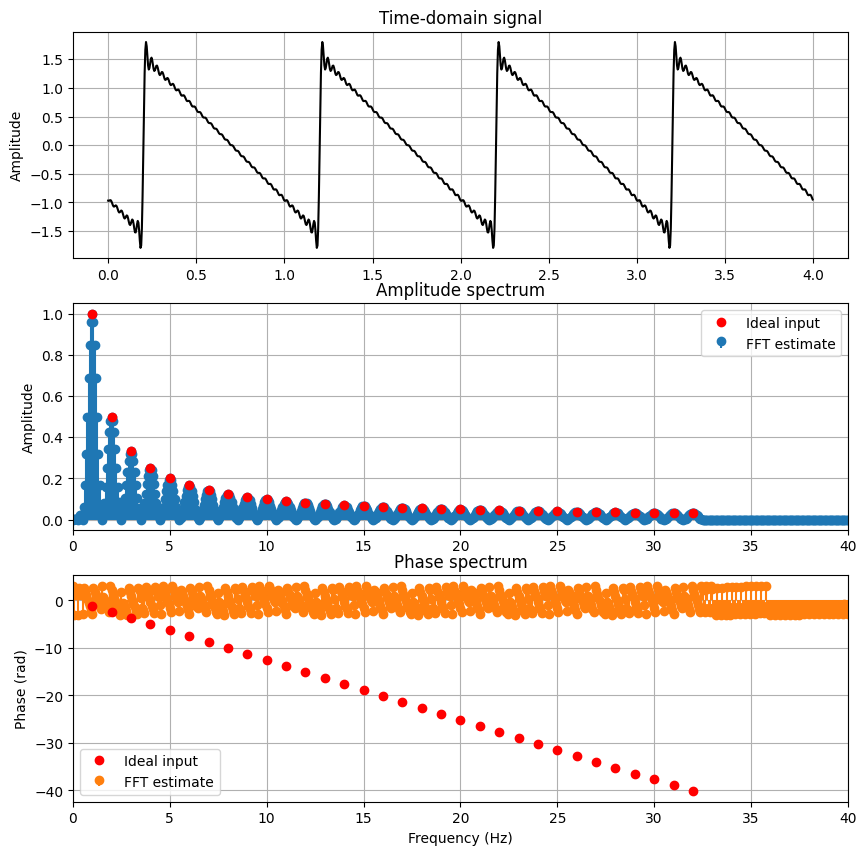

In [6]:
interact(
    explore_fft,
    amp_exp=FloatSlider(min=0.0, max=2.0, step=0.1, value=1.0,
                         description="Amplitude ∝ f⁻ⁿ"),
    phase_type=Dropdown(
        options=["zero", "linear", "scrambled"],
        value="linear",
        description="Phase type"
    ),
    phase_shift=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.2,
                            description="Time shift (s)"),
    pad_factor=IntSlider(min=1, max=8, step=1, value=4,
                         description="Padding ×"),
    window=Checkbox(value=True, description="Hann window")
);

### Interpreting the spectral comparison

The red markers show the **exact amplitudes and phases used to construct the signal**.
These values define the *true spectral model*.

The stems show the **FFT estimate** of those values from discretely sampled data.

Important points:
- The FFT is not expected to recover the model *exactly*
- Small offsets and amplitude differences are normal
- Finite record length, windowing, and sampling control the mismatch
- The goal is to recover the correct frequencies and approximate amplitudes and phases

This is exactly analogous to geophysical inversion:
we aim to recover a model that is *close enough* to explain the data,
not an exact replica of the true Earth.

### What you should notice

- Changing **phase** dramatically changes the waveform but not the amplitude spectrum
- Changing **amplitude decay** reshapes the spectrum but preserves phase structure
- Zero padding improves frequency resolution but does not add new information
- Windowing reduces spectral leakage and stabilises phase

These effects are not numerical artefacts — they reflect how Fourier transforms work.


## Key takeaways

- A signal is fully described by:
  - Frequencies
  - Amplitudes
  - Phases
- The amplitude spectrum alone is not unique
- Phase carries geometric and positional information
- Fourier transforms reorganise information — they do not interpret it

## Time–space analogy

| Time‑domain demo | Potential fields |
|------------------|------------------|
| Time | Distance |
| Frequency | Wavenumber |
| Sampling rate | Station spacing |
| Phase shift | Lateral offset |
| Filtering | Continuation |

**The Fourier transform does not care what the independent variable represents.**

This intuition will be critical for:
- Aliasing
- Upward/downward continuation
- Reduction to the pole